# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from scipy.stats import truncnorm, norm
from scipy.optimize import fsolve

In [5]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts
from core.selective_inference import *

# Simulation

In [6]:
params_dict = {
    'Atlanta Job Corps': (2093, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (785, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

# params_dict = {
#     'Atlanta Job Corps': (6546, 2288.40), 
#     'CET/San Jose': (6547, 1496.17), 
#     'Chicago Commons': (-1417, 2168.21), 
#     'Connelley (Pittsburgh)': (1343, 1681.92), 
#     'East LA Skills Center': (1343, 1735.51), 
#     'EGOS (Denver)': (401, 1329.05), 
#     'Phoenix Job Corps': (-1325, 1598.03), 
#     'SET/Corpus Christi': (485, 971.05), 
#     'EI Centro (Dallas)': (336, 1523.33), 
#     'LA Job Corps': (-121, 1409.79), 
#     'Allentown (Buffalo)': (904, 1814.10), 
#     'BSA (New York City)': (1424, 1768.44), 
#     'CREC (Hartford)': (-1370, 1860.45), 
# }

mu_arr = np.array([params_dict[site][0] for site in params_dict])
se_arr = np.array([params_dict[site][1] for site in params_dict])
cov_arr = np.diag(se_arr ** 2)  # the paper uses standard errors to contruct the covariance matrix

best_site_mu, best_site_se = params_dict['CET/San Jose']

best_scaling = 0.55

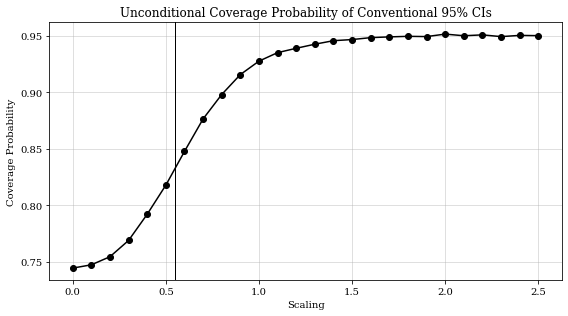

In [252]:
# coverage of conventional 95% CI
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
coverage_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]
    best_se_arr = se_arr[temp_best_site_arr]

    is_cover_arr = (best_mu_arr - 1.96 * best_se_arr <= max_est_arr) & (max_est_arr <= best_mu_arr + 1.96 * best_se_arr)
    coverage_arr[idx] = is_cover_arr.mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, coverage_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Coverage Probability')
ax.set_title('Unconditional Coverage Probability of Conventional 95% CIs')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, coverage_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr, best_se_arr, is_cover_arr

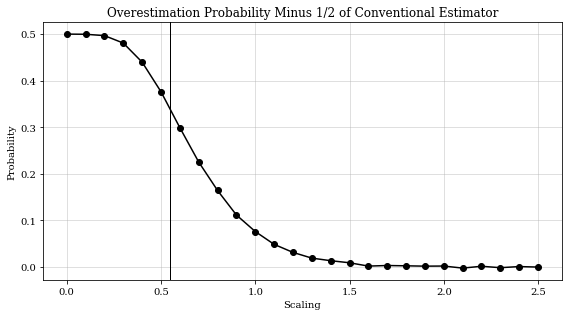

In [253]:
# Overestimation probability
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
overestimate_prob_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    overestimate_prob_arr[idx] = (max_est_arr >= best_mu_arr).mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, overestimate_prob_arr - 0.5, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Probability')
ax.set_title('Overestimation Probability Minus 1/2 of Conventional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, overestimate_prob_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

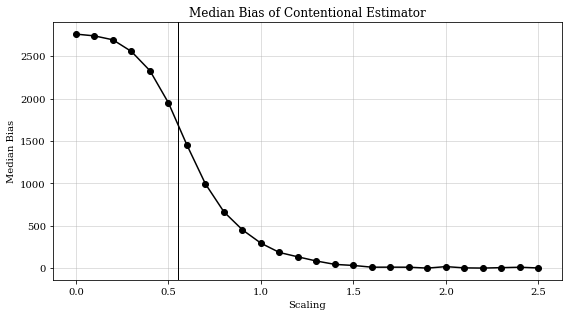

In [254]:
# median bias
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
median_bias_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    median_bias_arr[idx] = np.median(max_est_arr - best_mu_arr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, median_bias_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Median Bias')
ax.set_title('Median Bias of Contentional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, median_bias_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

# Model

In [7]:
params_dict = {
    'Atlanta Job Corps': (2093, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (785, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

mu_arr = np.array([params_dict[site][0] for site in params_dict])
se_arr = np.array([params_dict[site][1] for site in params_dict])
cov_arr = np.diag(se_arr ** 2)  # the paper uses standard errors to contruct the covariance matrix

best_site_mu, best_site_se = params_dict['CET/San Jose']

best_scaling = 0.55

## Conditional Inference

In [7]:
mean_arr = mu_arr
std_arr = se_arr

# calculate the related statistics
max_item_idx = mean_arr.argmax()
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the quantile
result = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)
median_est = result[0][0]

print('Median Estimate:', median_est)

Median Estimate: 6544.253866680862


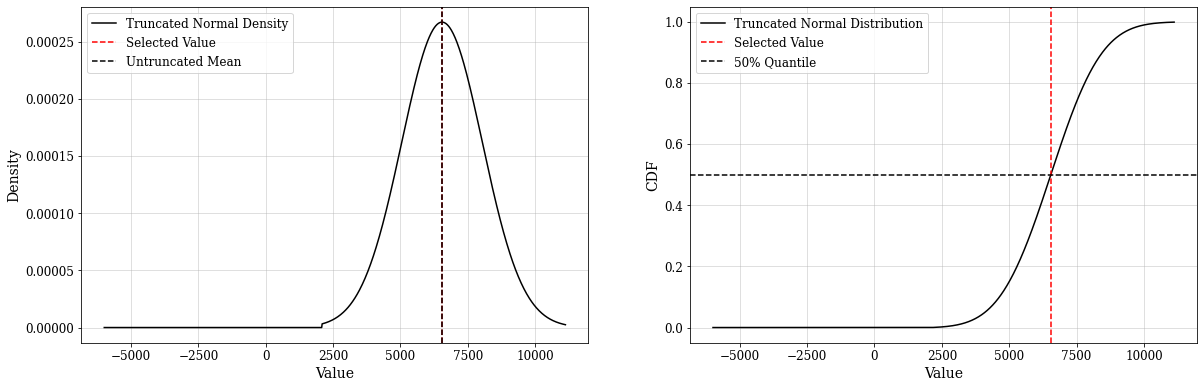

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(mean_arr.min() - 2 * std_arr.max(), mean_arr.max() + 2 * std_arr.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].axvline(median_est, color='black', linestyle='--', label='Untruncated Mean')

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [9]:
n_repeats = 5000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
    ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
    ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
        'est': median_est, 
    }

100%|██████████| 5000/5000 [00:15<00:00, 316.64it/s]


In [10]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
err_std = result_df['error'].std()
ci_width = result_df['ci_width'].median()

avg = result_df['est'].mean()
median = result_df['est'].median()

print(f'Average', avg)
print(f'Median', median)

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Error Std: {err_std:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Average -4798.272459294497
Median 2739.0121359056034
Coverage Probability: 94.44%
Overestimation Probability: 49.68%
Average Error: -7198.27
Median Error: -23.75
Error Std: 59986.71
Median CI Width: 12624.58


## Unconditional Inference

In [11]:
n_repeats = 100
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    ci_lb, ci_ub, _ = unconditional_inference(
        mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha, 
        n_simulations=100000
    )

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
    }

100%|██████████| 100/100 [00:03<00:00, 31.27it/s]


In [12]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
ci_width = result_df['ci_width'].median()

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Median CI Width: {ci_width:.2f}')

Coverage Probability: 97.00%
Median CI Width: 8634.06


## Hybrid

In [7]:
mean_arr = mu_arr
std_arr = se_arr

# calculate beta
alpha = 0.05
beta = alpha / 10

# if max_item_idx is not provided, find the index of the max item
max_item_idx = mean_arr.argmax()

# get the mean and std of the max item
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]

# calculate c_beta from projection method
_, _, c_beta = unconditional_inference(
    mean_arr, std_arr, max_item_idx=max_item_idx, alpha=beta, 
    n_simulations=500000
)

# get the second max mean
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the lb and ub of the truncated normal distribution
trunc_lb = max(second_max_mean, max_item_mean - c_beta * max_item_std)
trunc_ub = max_item_mean + c_beta * max_item_std
# trunc_ub = np.inf

# calculate the quantile
median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]

print('Truncated normal distribution: ')
print(f'Mean: {median_est:.2f}, SD: {max_item_std:.2f}')
print(f'Lower bound: {trunc_lb:.2f}, Upper bound: {trunc_ub:.2f}')

Truncated normal distribution: 
Mean: 6544.64, SD: 1496.17
Lower bound: 2093.00, Upper bound: 11865.02


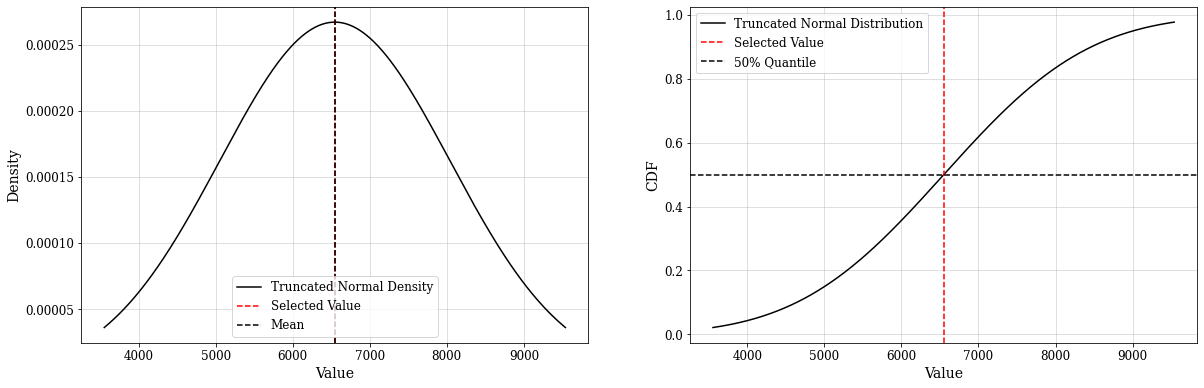

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(median_est - 2 * max_item_std, median_est + 2 * max_item_std, 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].axvline(truncnorm.mean(a=(second_max_mean - median_est) / max_item_std, b=np.inf, loc=median_est, scale=max_item_std), color='black', linestyle='--', label='Mean')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [17]:
n_repeats = 1000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
    ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
    ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]


    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
        'est': median_est,
    }

100%|██████████| 1000/1000 [00:23<00:00, 42.17it/s]


In [18]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
ci_width = result_df['ci_width'].median()

print('Average', result_df['est'].mean())
print('Median', result_df['est'].median())

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Average 2282.909555544169
Median 2741.740975399099
Coverage Probability: 95.80%
Overestimation Probability: 51.10%
Average Error: -58.94
Median Error: 98.83
Median CI Width: 8397.49


## Comparison

In [19]:
n_repeats = 100
alpha = 0.05
scaling_arr = np.arange(0, 2.6, 0.1)
result_records = [None] * (scaling_arr.size * n_repeats)

for idx, scaling in tqdm(enumerate(scaling_arr)):
    for j in range(n_repeats):
        mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
        std_arr = np.sqrt(np.diag(cov_arr))

        max_item_idx = mean_arr.argmax()
        max_item_val_true = scaling * mu_arr[max_item_idx]

        # Conventional
        conv_ci_lb = mean_arr[max_item_idx] - 1.96 * std_arr[max_item_idx]
        conv_ci_ub = mean_arr[max_item_idx] + 1.96 * std_arr[max_item_idx]

        # Conditional Inference
        cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
        cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

        # Unconditional Inference
        uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

        # Hybrid Inference
        hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
        hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]

        result_records[idx * n_repeats + j] = {
            'scaling': scaling, 
            'conv_ci_width': conv_ci_ub - conv_ci_lb,
            'cond_ci_width': cond_ci_ub - cond_ci_lb, 
            'uncond_ci_width': uncond_ci_ub - uncond_ci_lb,
            'hybrid_ci_width': hybrid_ci_ub - hybrid_ci_lb,
        }

26it [00:52,  2.01s/it]


In [20]:
result_df = pd.DataFrame.from_records(result_records)
median_ci_width_df = result_df.groupby('scaling').median()

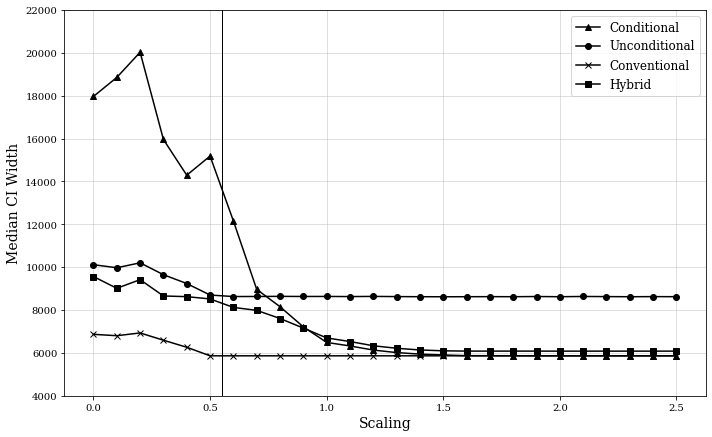

In [21]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(median_ci_width_df.index, median_ci_width_df['cond_ci_width'], marker='^', color='black', label='Conditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['uncond_ci_width'], marker='o', color='black', label='Unconditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['conv_ci_width'], marker='x', color='black', label='Conventional')
ax.plot(median_ci_width_df.index, median_ci_width_df['hybrid_ci_width'], marker='s', color='black', label='Hybrid')

ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)

ax.set_xlabel('Scaling', fontsize=axis_label_size)
ax.set_ylabel('Median CI Width', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

ax.set_ylim(4000, 22000)

plt.tight_layout()
plt.show()

In [8]:
# results summary
alpha = 0.05
mean_arr = mu_arr 
std_arr = se_arr

max_item_idx = mean_arr.argmax()

# conventional
conv_est = mean_arr[max_item_idx]
conv_ci_lb = mean_arr[max_item_idx] - norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]
conv_ci_ub = mean_arr[max_item_idx] + norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]

# conditional inference
cond_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

# unconditional inference
uncond_est = conv_est 
uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

# hybrid inference
hybrid_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]

corrected_inference_df = pd.DataFrame({
    'Conventional': {'Point Estimate': f'${conv_est}', 'CI': f'(${conv_ci_lb:.0f}, ${conv_ci_ub:.0f})'},
    'Conditional': {'Point Estimate': f'${cond_est:.0f}', 'CI': f'(${cond_ci_lb:.0f}, ${cond_ci_ub:.0f})'},
    'Unconditional': {'Point Estimate': f'${uncond_est}', 'CI': f'(${uncond_ci_lb:.0f}, ${uncond_ci_ub:.0f})'},
    'Hybrid': {'Point Estimate': f'${hybrid_est:.0f}', 'CI': f'(${hybrid_ci_lb:.0f}, ${hybrid_ci_ub:.0f})'},
}).T
corrected_inference_df

,Point Estimate,CI
Conventional,$6547,"($3615, $9479)"
Conditional,$6544,"($3494, $9479)"
Unconditional,$6547,"($2239, $10855)"
Hybrid,$6545,"($3429, $9577)"
